# Industry-Level Data Analyst Project
## E-Commerce Sales, Customer & Product Performance Analytics

**Business Goal:** Analyze e-commerce transactions to identify revenue drivers, customer behavior, product performance, operational issues, and actionable growth opportunities.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

**Portfolio Deliverables**
- Data quality assessment
- KPI analysis
- Exploratory data analysis
- Product/category/region/channel analysis
- Customer RFM segmentation
- K-Means customer clustering
- Discount and margin analysis
- Outlier detection
- Executive business recommendations


## 1. Business Questions

1. What are revenue, profit, orders, customers and average order value?
2. Which categories and products drive revenue?
3. Which regions and channels perform best?
4. How do revenue and profit change over time?
5. Which customer segments are most valuable?
6. How does discounting affect profitability?
7. Which transactions are potential outliers?
8. What actions should management prioritize?


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully")


Libraries loaded successfully


In [2]:
# Generate a realistic industry-style e-commerce transaction dataset
np.random.seed(42)

n = 12000
start = pd.Timestamp("2024-01-01")
end = pd.Timestamp("2025-12-31")

dates = pd.to_datetime(
    np.random.randint(start.value // 10**9, end.value // 10**9, n),
    unit="s"
)

customers = [f"CUST_{i:05d}" for i in range(1, 2201)]
products = [
    ("Laptop", "Electronics", 650),
    ("Smartphone", "Electronics", 420),
    ("Headphones", "Electronics", 90),
    ("Office Chair", "Furniture", 180),
    ("Desk", "Furniture", 220),
    ("Running Shoes", "Fashion", 85),
    ("Jacket", "Fashion", 110),
    ("Backpack", "Fashion", 55),
    ("Coffee Maker", "Home & Kitchen", 95),
    ("Air Fryer", "Home & Kitchen", 125),
    ("Blender", "Home & Kitchen", 70),
    ("Cookware Set", "Home & Kitchen", 140),
]

regions = ["North", "South", "East", "West", "Central"]
channels = ["Website", "Mobile App", "Marketplace"]
payment_methods = ["Credit Card", "Debit Card", "UPI", "Net Banking", "COD"]
statuses = ["Delivered", "Delivered", "Delivered", "Delivered", "Cancelled", "Returned"]

pidx = np.random.randint(0, len(products), n)
base_price = np.array([products[i][2] for i in pidx])

df = pd.DataFrame({
    "order_id": [f"ORD_{i:06d}" for i in range(1, n + 1)],
    "order_date": dates,
    "customer_id": np.random.choice(customers, n),
    "product": [products[i][0] for i in pidx],
    "category": [products[i][1] for i in pidx],
    "region": np.random.choice(regions, n, p=[.23, .22, .18, .22, .15]),
    "sales_channel": np.random.choice(channels, n, p=[.48, .32, .20]),
    "payment_method": np.random.choice(payment_methods, n),
    "quantity": np.random.choice([1,1,1,2,2,3,4], n),
    "unit_price": np.round(base_price * np.random.uniform(.88, 1.12, n), 2),
    "discount_pct": np.round(np.clip(np.random.beta(2, 8, n) * .55, 0, .55), 3),
    "order_status": np.random.choice(statuses, n),
    "customer_age": np.random.randint(18, 66, n)
})

df["gross_sales"] = np.round(df["unit_price"] * df["quantity"], 2)
df["revenue"] = np.round(df["gross_sales"] * (1 - df["discount_pct"]), 2)
df["estimated_cost"] = np.round(df["revenue"] * np.random.uniform(.48, .78, n), 2)
df["profit"] = np.round(df["revenue"] - df["estimated_cost"], 2)
df["profit_margin_pct"] = np.round(df["profit"] / df["revenue"] * 100, 2)

df.head()


,order_id,order_date,customer_id,product,category,region,sales_channel,payment_method,quantity,unit_price,discount_pct,order_status,customer_age,gross_sales,revenue,estimated_cost,profit,profit_margin_pct
0,ORD_000001,2025-10-18 21:17:16,CUST_00032,Jacket,Fashion,North,Mobile App,COD,1,121.24,0.24,Delivered,28,121.24,92.02,61.58,30.44,33.08
1,ORD_000002,2025-07-28 15:21:50,CUST_00177,Desk,Furniture,West,Website,Net Banking,1,196.89,0.04,Delivered,21,196.89,188.23,121.08,67.15,35.67
2,ORD_000003,2025-10-20 08:38:02,CUST_02113,Jacket,Fashion,North,Website,Credit Card,1,123.18,0.11,Delivered,19,123.18,109.88,80.61,29.27,26.64
3,ORD_000004,2025-11-30 05:23:19,CUST_02075,Smartphone,Electronics,Central,Website,Net Banking,4,448.90,0.03,Delivered,20,"1,795.60","1,736.35","1,074.71",661.64,38.11
4,ORD_000005,2024-09-01 00:03:08,CUST_01503,Running Shoes,Fashion,West,Website,Credit Card,3,82.46,0.06,Cancelled,46,247.38,231.80,141.71,90.09,38.87


## 2. Data Quality Assessment

In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique()
}).sort_values("missing_count", ascending=False)

display(quality)
print("Duplicate rows:", df.duplicated().sum())


Rows: 12000
Columns: 18


,order_id,order_date,customer_id,product,category,region,sales_channel,payment_method,quantity,unit_price,discount_pct,order_status,customer_age,gross_sales,revenue,estimated_cost,profit,profit_margin_pct
0,ORD_000001,2025-10-18 21:17:16,CUST_00032,Jacket,Fashion,North,Mobile App,COD,1,121.24,0.24,Delivered,28,121.24,92.02,61.58,30.44,33.08
1,ORD_000002,2025-07-28 15:21:50,CUST_00177,Desk,Furniture,West,Website,Net Banking,1,196.89,0.04,Delivered,21,196.89,188.23,121.08,67.15,35.67
2,ORD_000003,2025-10-20 08:38:02,CUST_02113,Jacket,Fashion,North,Website,Credit Card,1,123.18,0.11,Delivered,19,123.18,109.88,80.61,29.27,26.64
3,ORD_000004,2025-11-30 05:23:19,CUST_02075,Smartphone,Electronics,Central,Website,Net Banking,4,448.90,0.03,Delivered,20,"1,795.60","1,736.35","1,074.71",661.64,38.11
4,ORD_000005,2024-09-01 00:03:08,CUST_01503,Running Shoes,Fashion,West,Website,Credit Card,3,82.46,0.06,Cancelled,46,247.38,231.80,141.71,90.09,38.87


,dtype,missing_count,missing_pct,unique_values
order_id,object,0,0.00,12000
order_date,datetime64[ns],0,0.00,11998
profit,float64,0,0.00,9015
estimated_cost,float64,0,0.00,10020
revenue,float64,0,0.00,10618
gross_sales,float64,0,0.00,10453
customer_age,int32,0,0.00,48
order_status,object,0,0.00,3
discount_pct,float64,0,0.00,355
unit_price,float64,0,0.00,9095


Duplicate rows: 0


In [4]:
# Business-rule validation
checks = pd.Series({
    "negative_revenue": (df["revenue"] < 0).sum(),
    "invalid_quantity": (df["quantity"] <= 0).sum(),
    "invalid_discount": ((df["discount_pct"] < 0) | (df["discount_pct"] > 1)).sum(),
    "negative_profit": (df["profit"] < 0).sum()
})
display(checks.to_frame("issue_count"))


,issue_count
negative_revenue,0
invalid_quantity,0
invalid_discount,0
negative_profit,0


## 3. Feature Engineering

In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["quarter"] = "Q" + df["order_date"].dt.quarter.astype(str)
df["weekday"] = df["order_date"].dt.day_name()
df["successful_order"] = df["order_status"].eq("Delivered")

df["discount_band"] = pd.cut(
    df["discount_pct"],
    bins=[-0.01, .10, .20, .30, .40, 1],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40%+"]
)

df.head()


,order_id,order_date,customer_id,product,category,region,sales_channel,payment_method,quantity,unit_price,discount_pct,order_status,customer_age,gross_sales,revenue,estimated_cost,profit,profit_margin_pct,year,month,month_name,quarter,weekday,successful_order,discount_band
0,ORD_000001,2025-10-18 21:17:16,CUST_00032,Jacket,Fashion,North,Mobile App,COD,1,121.24,0.24,Delivered,28,121.24,92.02,61.58,30.44,33.08,2025,10,October,Q4,Saturday,True,20-30%
1,ORD_000002,2025-07-28 15:21:50,CUST_00177,Desk,Furniture,West,Website,Net Banking,1,196.89,0.04,Delivered,21,196.89,188.23,121.08,67.15,35.67,2025,7,July,Q3,Monday,True,0-10%
2,ORD_000003,2025-10-20 08:38:02,CUST_02113,Jacket,Fashion,North,Website,Credit Card,1,123.18,0.11,Delivered,19,123.18,109.88,80.61,29.27,26.64,2025,10,October,Q4,Monday,True,10-20%
3,ORD_000004,2025-11-30 05:23:19,CUST_02075,Smartphone,Electronics,Central,Website,Net Banking,4,448.90,0.03,Delivered,20,"1,795.60","1,736.35","1,074.71",661.64,38.11,2025,11,November,Q4,Sunday,True,0-10%
4,ORD_000005,2024-09-01 00:03:08,CUST_01503,Running Shoes,Fashion,West,Website,Credit Card,3,82.46,0.06,Cancelled,46,247.38,231.80,141.71,90.09,38.87,2024,9,September,Q3,Sunday,False,0-10%


## 4. Executive KPIs

In [6]:
delivered = df[df["order_status"] == "Delivered"].copy()

kpis = pd.Series({
    "Revenue": delivered["revenue"].sum(),
    "Profit": delivered["profit"].sum(),
    "Orders": delivered["order_id"].nunique(),
    "Customers": delivered["customer_id"].nunique(),
    "Average Order Value": delivered["revenue"].sum() / delivered["order_id"].nunique(),
    "Profit Margin %": delivered["profit"].sum() / delivered["revenue"].sum() * 100,
    "Return/Cancel Rate %": (~df["successful_order"]).mean() * 100
})

display(kpis.round(2))


Revenue                2,702,057.14
Profit                   999,036.93
Orders                     8,068.00
Customers                  2,140.00
Average Order Value          334.91
Profit Margin %               36.97
Return/Cancel Rate %          32.77
dtype: float64

## 5. Monthly Revenue & Profit Trend

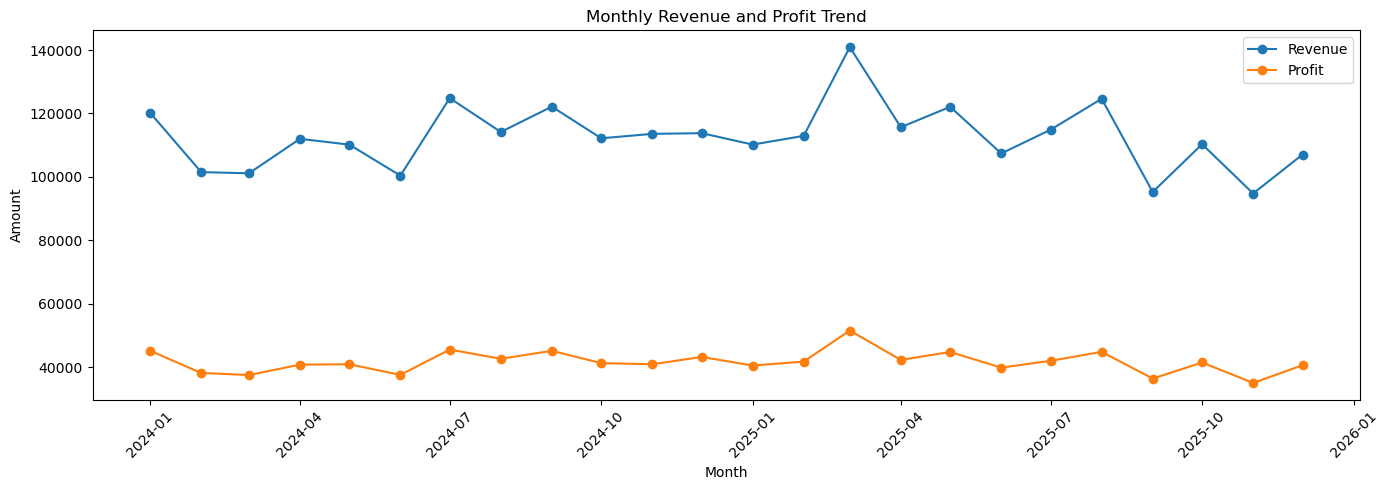

In [7]:
monthly = delivered.groupby(
    delivered["order_date"].dt.to_period("M")
).agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "nunique")
).reset_index()

monthly["order_date"] = monthly["order_date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["order_date"], monthly["revenue"], marker="o", label="Revenue")
ax.plot(monthly["order_date"], monthly["profit"], marker="o", label="Profit")
ax.set_title("Monthly Revenue and Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Amount")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Category Performance

,revenue,profit,orders,units,profit_margin_pct
category,,,,,
Electronics,"1,424,116.64","525,291.99",2086,4146,36.89
Home & Kitchen,"499,806.54","185,030.35",2633,5257,37.02
Furniture,"478,549.69","177,499.88",1314,2689,37.09
Fashion,"299,584.27","111,214.71",2035,4050,37.12


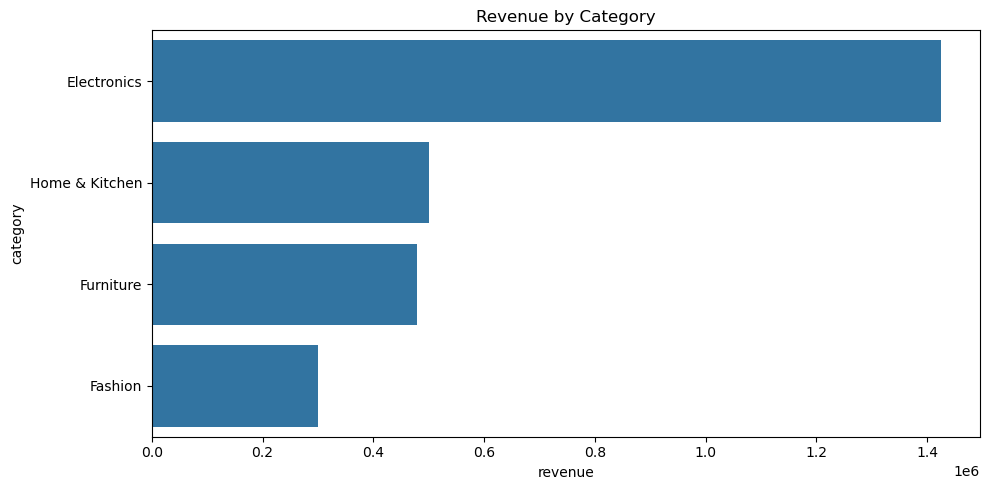

In [8]:
category_perf = delivered.groupby("category").agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "nunique"),
    units=("quantity", "sum")
).sort_values("revenue", ascending=False)

category_perf["profit_margin_pct"] = (
    category_perf["profit"] / category_perf["revenue"] * 100
)

display(category_perf.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(data=category_perf.reset_index(), x="revenue", y="category")
plt.title("Revenue by Category")
plt.tight_layout()
plt.show()


## 7. Product Performance

In [9]:
product_perf = delivered.groupby(
    ["product", "category"]
).agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    units=("quantity", "sum"),
    orders=("order_id", "nunique")
).sort_values("revenue", ascending=False)

product_perf["profit_margin_pct"] = product_perf["profit"] / product_perf["revenue"] * 100

display(product_perf.head(15).round(2))


,,revenue,profit,units,orders,profit_margin_pct
product,category,,,,,
Laptop,Electronics,"799,034.01","292,543.47",1386,698,36.61
Smartphone,Electronics,"514,328.84","191,695.03",1386,697,37.27
Desk,Furniture,"262,192.78","98,167.71",1346,655,37.44
Office Chair,Furniture,"216,356.91","79,332.17",1343,659,36.67
Air Fryer,Home & Kitchen,"152,890.00","56,399.45",1385,705,36.89
Cookware Set,Home & Kitchen,"150,149.93","55,649.49",1197,626,37.06
Jacket,Fashion,"131,813.73","49,410.65",1345,680,37.49
Coffee Maker,Home & Kitchen,"117,090.63","44,129.66",1395,676,37.69
Headphones,Electronics,"110,753.79","41,053.49",1374,691,37.07


## 8. Regional & Channel Analysis

,revenue,profit,orders
region,,,
North,"627,156.21","230,936.89",1874
South,"603,760.34","219,882.78",1800
West,"590,573.83","220,919.94",1795
East,"479,605.70","178,210.21",1432
Central,"400,961.06","149,087.11",1167


,revenue,profit,orders
sales_channel,,,
Website,"1,293,711.79","479,699.39",3888
Mobile App,"858,404.27","317,188.79",2531
Marketplace,"549,941.08","202,148.75",1649


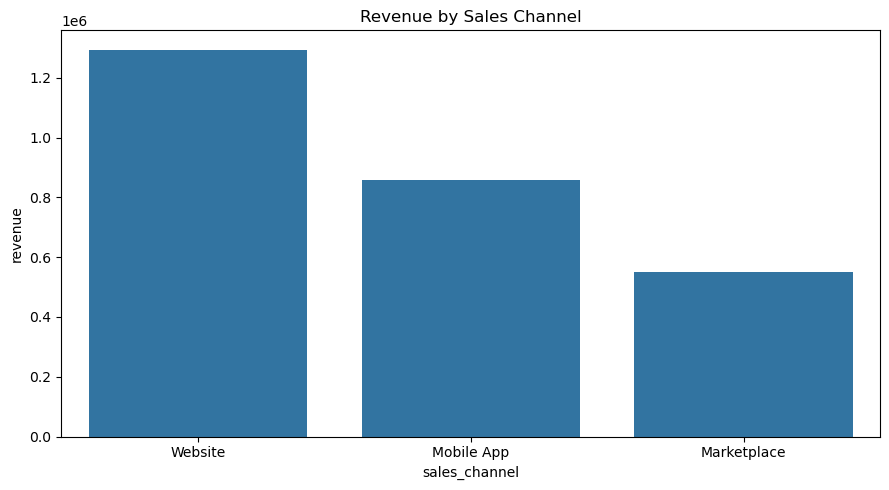

In [10]:
region_perf = delivered.groupby("region").agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "nunique")
).sort_values("revenue", ascending=False)

channel_perf = delivered.groupby("sales_channel").agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "nunique")
).sort_values("revenue", ascending=False)

display(region_perf.round(2))
display(channel_perf.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=channel_perf.reset_index(), x="sales_channel", y="revenue")
plt.title("Revenue by Sales Channel")
plt.tight_layout()
plt.show()


## 9. Discount vs Profitability

,discount_band,revenue,profit,orders,profit_margin_pct
0,0-10%,"1,430,354.36","527,606.35",4089,36.89
1,10-20%,"1,025,603.87","379,753.19",3112,37.03
2,20-30%,"224,857.32","83,697.04",787,37.22
3,30-40%,"21,241.59","7,980.35",80,37.57


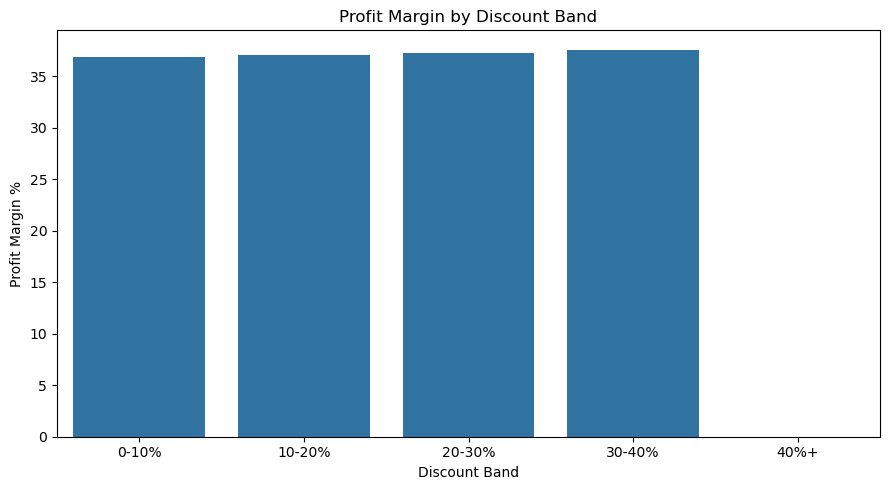

In [11]:
discount_analysis = delivered.groupby(
    "discount_band", observed=True
).agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "nunique")
).reset_index()

discount_analysis["profit_margin_pct"] = (
    discount_analysis["profit"] / discount_analysis["revenue"] * 100
)

display(discount_analysis.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=discount_analysis, x="discount_band", y="profit_margin_pct")
plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin %")
plt.tight_layout()
plt.show()


## 10. RFM Customer Segmentation

**RFM = Recency, Frequency and Monetary Value.**

This framework is widely used to prioritize customer retention, loyalty and marketing actions.


In [12]:
snapshot_date = delivered["order_date"].max() + pd.Timedelta(days=1)

rfm = delivered.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum")
).reset_index()

rfm["R_score"] = pd.qcut(
    rfm["recency"].rank(method="first"), 5,
    labels=[5,4,3,2,1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"), 5,
    labels=[1,2,3,4,5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"), 5,
    labels=[1,2,3,4,5]
).astype(int)

rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segment(row):
    if row["RFM_score"] >= 13:
        return "Champions"
    elif row["RFM_score"] >= 10:
        return "Loyal Customers"
    elif row["RFM_score"] >= 7:
        return "Potential / Regular"
    return "At Risk"

rfm["segment"] = rfm.apply(segment, axis=1)

display(rfm.head())
display(rfm["segment"].value_counts())


,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,CUST_00001,150,3,900.63,3,2,3,8,Potential / Regular
1,CUST_00002,140,4,452.77,3,3,1,7,Potential / Regular
2,CUST_00003,281,1,671.64,2,1,2,5,At Risk
3,CUST_00004,58,4,589.42,4,3,2,9,Potential / Regular
4,CUST_00005,53,4,997.12,4,3,3,10,Loyal Customers


segment
Loyal Customers        635
Potential / Regular    581
At Risk                552
Champions              372
Name: count, dtype: int64

,customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
Champions,372,50.41,6.16,"2,392.09"
Loyal Customers,635,119.40,4.57,"1,601.97"
Potential / Regular,581,177.55,3.13,953.04
At Risk,552,340.56,1.90,437.02


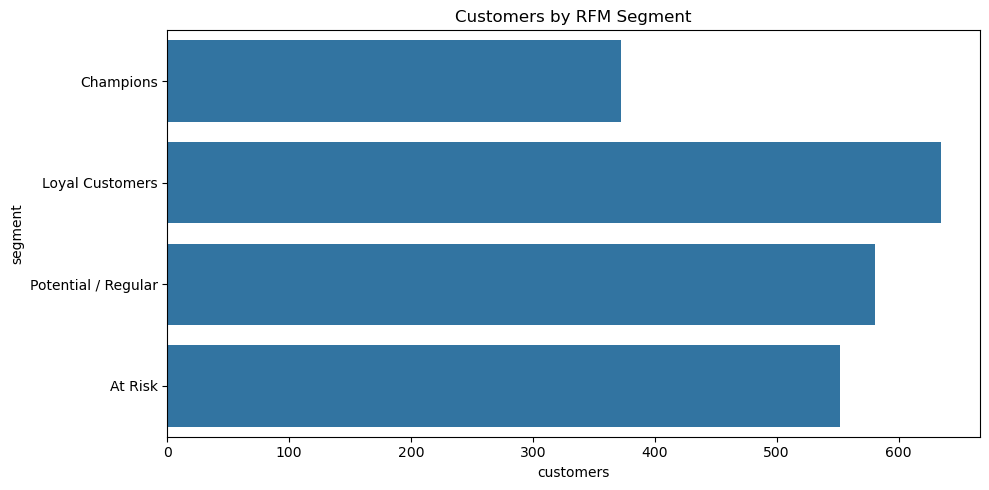

In [13]:
segment_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean")
).sort_values("avg_monetary", ascending=False)

display(segment_summary.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_summary.reset_index(), x="customers", y="segment")
plt.title("Customers by RFM Segment")
plt.tight_layout()
plt.show()


## 11. Revenue Concentration

In [14]:
customer_value = (
    delivered.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_10_count = max(1, int(len(customer_value) * .10))
top_10_share = customer_value.head(top_10_count).sum() / customer_value.sum() * 100

print(f"Top 10% of customers contribute approximately {top_10_share:.2f}% of delivered revenue.")


Top 10% of customers contribute approximately 26.85% of delivered revenue.


## 12. Order Status / Operational Analysis

,orders,revenue,order_share_pct
order_status,,,
Delivered,8068,"2,702,057.14",67.23
Returned,2007,"670,317.27",16.73
Cancelled,1925,"616,806.05",16.04


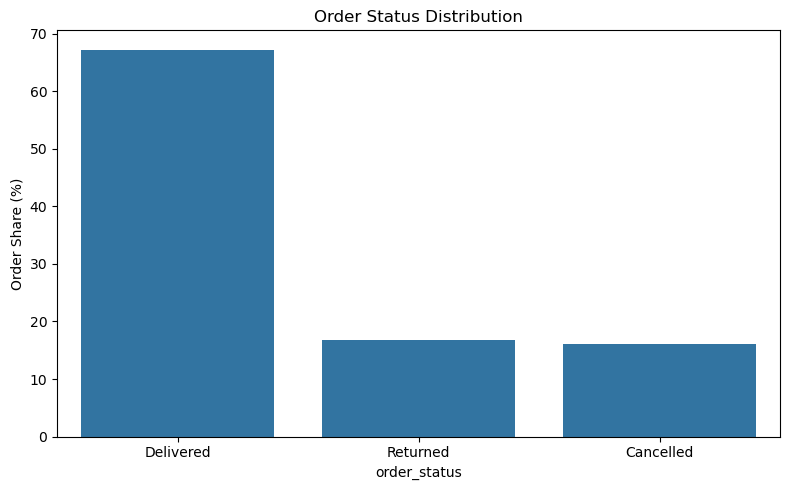

In [15]:
status_analysis = df.groupby("order_status").agg(
    orders=("order_id", "nunique"),
    revenue=("revenue", "sum")
).sort_values("orders", ascending=False)

status_analysis["order_share_pct"] = (
    status_analysis["orders"] / status_analysis["orders"].sum() * 100
)

display(status_analysis.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=status_analysis.reset_index(), x="order_status", y="order_share_pct")
plt.title("Order Status Distribution")
plt.ylabel("Order Share (%)")
plt.tight_layout()
plt.show()


## 13. Revenue Outlier Detection using IQR

In [16]:
q1 = delivered["revenue"].quantile(.25)
q3 = delivered["revenue"].quantile(.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = delivered[
    (delivered["revenue"] < lower) |
    (delivered["revenue"] > upper)
]

print("Lower bound:", round(lower, 2))
print("Upper bound:", round(upper, 2))
print("Potential outlier orders:", len(outliers))

display(
    outliers[
        ["order_id", "customer_id", "product", "category", "revenue", "profit"]
    ].sort_values("revenue", ascending=False).head(10)
)


Lower bound: -297.46
Upper bound: 786.06
Potential outlier orders: 700


,order_id,customer_id,product,category,revenue,profit
1290,ORD_001291,CUST_01848,Laptop,Electronics,"2,805.59","1,030.21"
243,ORD_000244,CUST_00762,Laptop,Electronics,"2,803.94",977.83
11005,ORD_011006,CUST_00458,Laptop,Electronics,"2,775.87","1,286.36"
7205,ORD_007206,CUST_01722,Laptop,Electronics,"2,771.92",966.99
4041,ORD_004042,CUST_00329,Laptop,Electronics,"2,705.10","1,278.31"
4920,ORD_004921,CUST_01626,Laptop,Electronics,"2,700.22","1,237.80"
1931,ORD_001932,CUST_00509,Laptop,Electronics,"2,668.07","1,034.71"
916,ORD_000917,CUST_00687,Laptop,Electronics,"2,649.23",687.32
6913,ORD_006914,CUST_01108,Laptop,Electronics,"2,625.59",764.99
4405,ORD_004406,CUST_00967,Laptop,Electronics,"2,621.59",839.25


## 14. K-Means Customer Clustering

In [17]:
features = rfm[["recency", "frequency", "monetary"]]

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X)

cluster_summary = rfm.groupby("cluster").agg(
    customers=("customer_id", "count"),
    recency=("recency", "mean"),
    frequency=("frequency", "mean"),
    monetary=("monetary", "mean")
).sort_values("monetary", ascending=False)

display(cluster_summary.round(2))


,customers,recency,frequency,monetary
cluster,,,,
1,284,110.67,6.38,"3,051.11"
2,736,112.83,4.78,"1,495.51"
3,404,449.18,2.16,702.32
0,716,125.38,2.60,630.04


## 15. Correlation Analysis

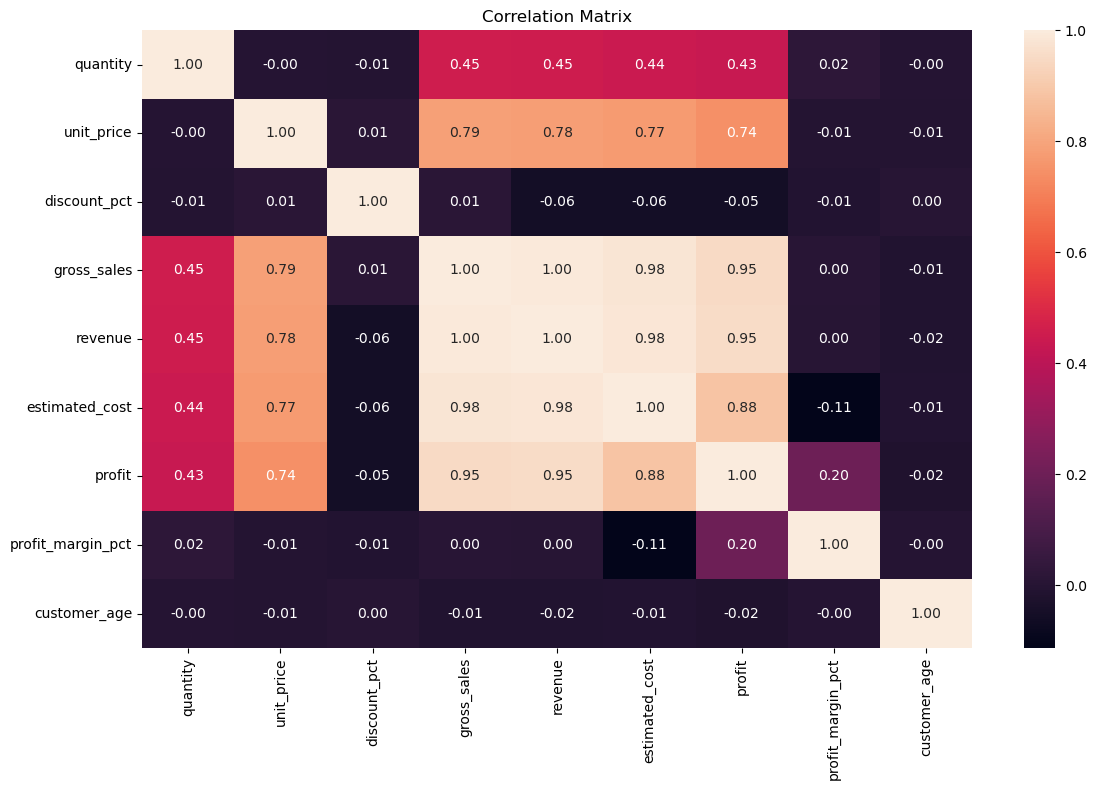

In [18]:
numeric_cols = [
    "quantity", "unit_price", "discount_pct",
    "gross_sales", "revenue", "estimated_cost",
    "profit", "profit_margin_pct", "customer_age"
]

corr = delivered[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 16. SQL-Style Analysis in Pandas

In [19]:
# Top 10 products by revenue
top_products = (
    delivered.groupby("product")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
display(top_products)

# Monthly revenue
monthly_revenue = (
    delivered.assign(month=delivered["order_date"].dt.to_period("M"))
    .groupby("month")["revenue"]
    .sum()
)
display(monthly_revenue.tail(12))

# Top 20 customers
top_customers = (
    delivered.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)
display(top_customers)


product
Laptop          799,034.01
Smartphone      514,328.84
Desk            262,192.78
Office Chair    216,356.91
Air Fryer       152,890.00
Cookware Set    150,149.93
Jacket          131,813.73
Coffee Maker    117,090.63
Headphones      110,753.79
Running Shoes   101,277.79
Name: revenue, dtype: float64

month
2025-01   110,180.07
2025-02   112,935.39
2025-03   140,927.43
2025-04   115,663.69
2025-05   122,103.29
2025-06   107,375.14
2025-07   114,879.55
2025-08   124,631.94
2025-09    95,222.94
2025-10   110,303.29
2025-11    94,747.83
2025-12   107,032.28
Freq: M, Name: revenue, dtype: float64

customer_id
CUST_01461   6,020.10
CUST_02131   5,764.96
CUST_00347   5,569.40
CUST_01722   5,488.62
CUST_01240   5,387.29
CUST_00744   5,285.66
CUST_00094   5,228.77
CUST_01773   5,121.75
CUST_01769   5,101.15
CUST_02125   5,075.77
CUST_01978   4,978.48
CUST_01626   4,943.86
CUST_00842   4,843.80
CUST_00798   4,750.44
CUST_01837   4,683.78
CUST_01277   4,656.05
CUST_01061   4,600.57
CUST_01891   4,551.00
CUST_01939   4,504.72
CUST_01261   4,419.44
Name: revenue, dtype: float64

## 17. Executive Business Recommendations

In [20]:
best_category = category_perf.index[0]
best_product = product_perf.index[0][0]
best_region = region_perf.index[0]
best_channel = channel_perf.index[0]
best_segment = segment_summary.index[0]

print("EXECUTIVE SUMMARY")
print("=" * 70)
print(f"Revenue: ₹{delivered['revenue'].sum():,.0f}")
print(f"Profit: ₹{delivered['profit'].sum():,.0f}")
print(f"Average Order Value: ₹{delivered['revenue'].mean():,.2f}")
print(f"Leading Category: {best_category}")
print(f"Leading Product: {best_product}")
print(f"Leading Region: {best_region}")
print(f"Leading Channel: {best_channel}")
print(f"Highest-value RFM segment: {best_segment}")
print(f"Return/Cancel Rate: {(~df['successful_order']).mean()*100:.2f}%")

print("\nRECOMMENDED ACTIONS")
print("1. Protect and expand high-revenue/high-margin categories.")
print("2. Build retention campaigns for At Risk customers.")
print("3. Avoid blanket discounts; optimize promotions around margin.")
print("4. Invest in channels and regions that produce strong profit.")
print("5. Investigate cancellation/return drivers operationally.")
print("6. Review unusually large transactions for business or data-quality causes.")


EXECUTIVE SUMMARY
Revenue: ₹2,702,057
Profit: ₹999,037
Average Order Value: ₹334.91
Leading Category: Electronics
Leading Product: Laptop
Leading Region: North
Leading Channel: Website
Highest-value RFM segment: Champions
Return/Cancel Rate: 32.77%

RECOMMENDED ACTIONS
1. Protect and expand high-revenue/high-margin categories.
2. Build retention campaigns for At Risk customers.
3. Avoid blanket discounts; optimize promotions around margin.
4. Invest in channels and regions that produce strong profit.
5. Investigate cancellation/return drivers operationally.
6. Review unusually large transactions for business or data-quality causes.


## 18. Machine Learning: Order Risk Prediction

A supervised model can help operations prioritize orders that may be cancelled or returned. The model uses only information available when an order is placed, so the target status is not included as a predictor.

Order-risk model evaluation
Accuracy: 0.621
F1 score: 0.201
ROC-AUC: 0.502

Classification report
                    precision    recall  f1-score   support

         Delivered       0.67      0.85      0.75      1614
Cancelled/Returned       0.32      0.15      0.20       786

          accuracy                           0.62      2400
         macro avg       0.50      0.50      0.48      2400
      weighted avg       0.56      0.62      0.57      2400



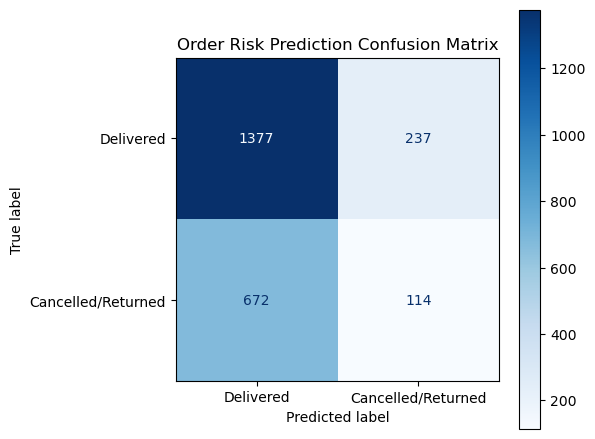

In [21]:
# Machine learning imports
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score
)

# Predict non-delivered orders using order-time attributes only
ml_data = df.copy()
ml_data["risk_target"] = (~ml_data["order_status"].eq("Delivered")).astype(int)
ml_data["order_month"] = ml_data["order_date"].dt.month
ml_data["order_weekday"] = ml_data["order_date"].dt.weekday

feature_columns = [
    "customer_age", "quantity", "unit_price", "discount_pct",
    "product", "category", "region", "sales_channel", "payment_method",
    "order_month", "order_weekday"
]

X = ml_data[feature_columns]
y = ml_data["risk_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_features = [
    "product", "category", "region", "sales_channel", "payment_method"
]
numeric_features = [
    "customer_age", "quantity", "unit_price", "discount_pct",
    "order_month", "order_weekday"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

risk_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=250,
            max_depth=12,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

risk_model.fit(X_train, y_train)
y_pred = risk_model.predict(X_test)
y_probability = risk_model.predict_proba(X_test)[:, 1]

print("Order-risk model evaluation")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_probability):.3f}")
print("\nClassification report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Delivered", "Cancelled/Returned"]
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Delivered", "Cancelled/Returned"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Order Risk Prediction Confusion Matrix")
plt.tight_layout()
plt.show()

## 19. Machine Learning: Revenue Prediction

Revenue prediction supports inventory planning and sales forecasting. This model predicts order revenue from attributes known at order time and is evaluated on unseen test data.

Revenue prediction model evaluation
MAE: ₹3.37
RMSE: ₹9.94
Test R²: 0.999
5-fold cross-validation R²: 0.999 +/- 0.000


,actual_revenue,predicted_revenue
0,"1,136.83","1,134.33"
1,51.99,52.24
2,89.79,93.79
3,57.00,57.00
4,103.08,102.85
5,561.29,569.76
6,54.45,53.90
7,"1,222.98","1,229.97"
8,645.13,638.06
9,122.40,120.99


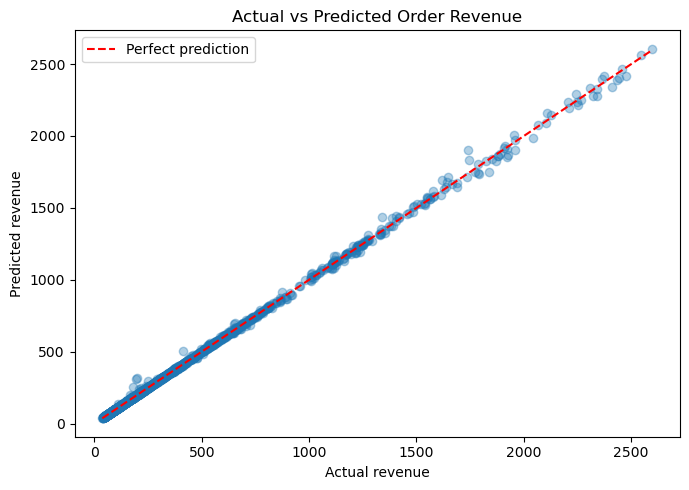

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

revenue_features = [
    "customer_age", "quantity", "unit_price", "discount_pct",
    "product", "category", "region", "sales_channel", "payment_method"
]
revenue_categorical = [
    "product", "category", "region", "sales_channel", "payment_method"
]
revenue_numeric = [
    "customer_age", "quantity", "unit_price", "discount_pct"
]

X_revenue = df[revenue_features]
y_revenue = df["revenue"]

X_revenue_train, X_revenue_test, y_revenue_train, y_revenue_test = train_test_split(
    X_revenue,
    y_revenue,
    test_size=0.20,
    random_state=42
)

revenue_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), revenue_categorical),
        ("numeric", "passthrough", revenue_numeric)
    ]
)

revenue_model = Pipeline(
    steps=[
        ("preprocessor", revenue_preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=250,
            max_depth=14,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

revenue_model.fit(X_revenue_train, y_revenue_train)
y_revenue_pred = revenue_model.predict(X_revenue_test)

mae = mean_absolute_error(y_revenue_test, y_revenue_pred)
rmse = np.sqrt(mean_squared_error(y_revenue_test, y_revenue_pred))
r2 = r2_score(y_revenue_test, y_revenue_pred)
cv_r2 = cross_val_score(
    revenue_model,
    X_revenue,
    y_revenue,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Revenue prediction model evaluation")
print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"Test R²: {r2:.3f}")
print(f"5-fold cross-validation R²: {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}")

prediction_check = pd.DataFrame({
    "actual_revenue": y_revenue_test.values,
    "predicted_revenue": np.round(y_revenue_pred, 2)
})
display(prediction_check.head(10))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_revenue_test, y_revenue_pred, alpha=0.35)
ax.plot(
    [y_revenue_test.min(), y_revenue_test.max()],
    [y_revenue_test.min(), y_revenue_test.max()],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)
ax.set_title("Actual vs Predicted Order Revenue")
ax.set_xlabel("Actual revenue")
ax.set_ylabel("Predicted revenue")
ax.legend()
plt.tight_layout()
plt.show()

## 20. Customer Retention and Cohort Analysis

Cohort analysis shows whether customers return after their first purchase and helps evaluate retention opportunities.

Repeat-purchase customer rate: 89.11%


cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,
2024-01,100.00,13.10,14.30,15.90,18.30,15.20,12.80,15.20,18.30,14.60,13.40,16.80,17.40,14.30,16.20,14.30,13.70,11.90,12.20,14.60,13.40,14.90,11.90,15.20
2024-02,100.00,16.90,15.30,15.30,14.50,10.00,13.30,18.50,14.90,16.10,12.90,10.00,13.70,16.90,13.30,15.70,15.70,11.60,15.30,9.60,11.60,12.90,17.30,NaN
2024-03,100.00,11.20,15.40,12.10,12.10,15.90,10.30,13.10,12.60,12.60,10.70,13.10,16.80,13.60,15.00,8.90,16.80,12.10,13.60,17.30,11.20,11.70,NaN,NaN
2024-04,100.00,14.10,12.00,17.70,8.90,14.10,14.10,9.40,16.70,18.20,13.50,14.60,14.10,19.80,10.40,8.30,13.50,15.10,7.30,12.50,19.30,NaN,NaN,NaN
2024-05,100.00,17.00,15.90,15.40,16.50,15.40,13.20,9.30,16.50,13.70,17.00,14.30,16.50,11.00,13.20,12.60,13.20,16.50,16.50,13.20,NaN,NaN,NaN,NaN
2024-06,100.00,18.10,14.50,12.30,16.70,12.30,13.00,14.50,13.80,13.80,16.70,18.80,16.70,16.70,18.80,19.60,18.10,13.00,15.20,NaN,NaN,NaN,NaN,NaN
2024-07,100.00,18.60,15.70,17.90,15.00,13.60,11.40,12.90,16.40,14.30,14.30,15.00,16.40,15.70,18.60,11.40,11.40,16.40,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,100.00,13.90,15.70,10.20,9.30,13.00,12.00,13.00,10.20,17.60,15.70,15.70,19.40,14.80,17.60,22.20,15.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.00,9.60,13.30,14.50,13.30,13.30,12.00,18.10,12.00,16.90,9.60,13.30,16.90,13.30,12.00,8.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


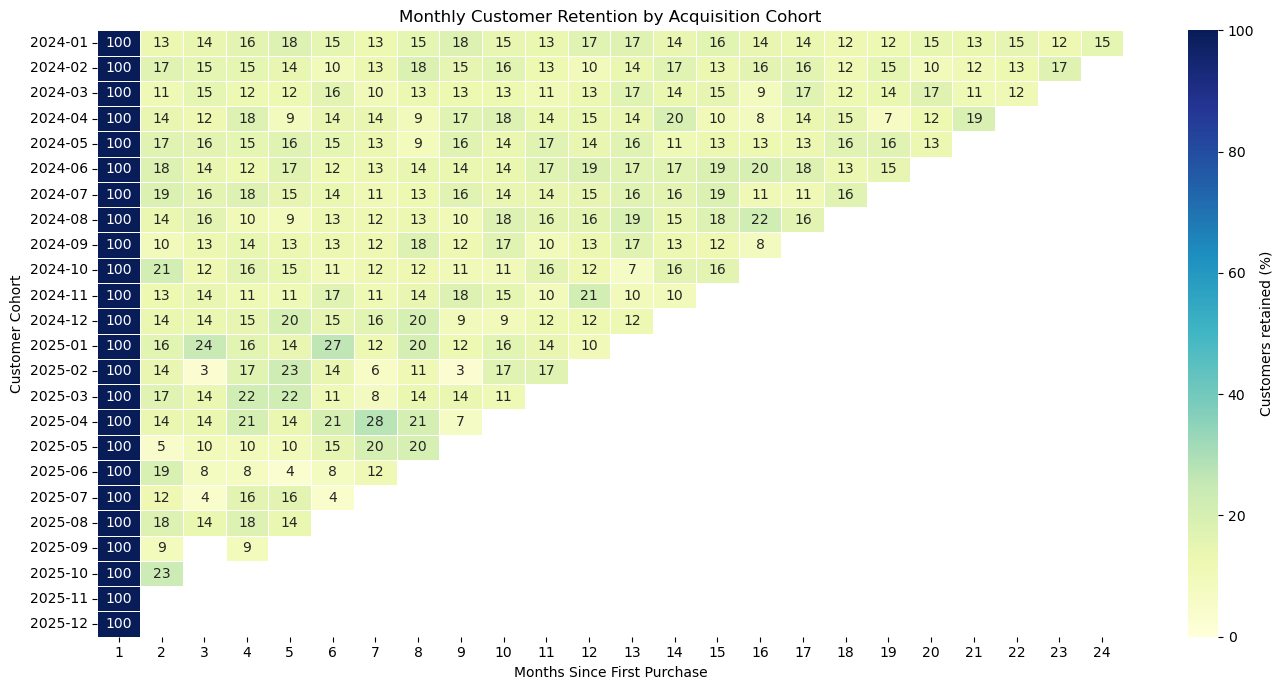

In [23]:
cohort_data = delivered[["customer_id", "order_date", "revenue"]].copy()
cohort_data["order_month"] = cohort_data["order_date"].dt.to_period("M")
cohort_data["cohort_month"] = cohort_data.groupby("customer_id")["order_month"].transform("min")
cohort_data["cohort_index"] = (
    (cohort_data["order_month"].dt.year - cohort_data["cohort_month"].dt.year) * 12
    + cohort_data["order_month"].dt.month
    - cohort_data["cohort_month"].dt.month
    + 1
)

cohort_counts = cohort_data.groupby(
    ["cohort_month", "cohort_index"]
)["customer_id"].nunique().reset_index()
cohort_sizes = cohort_counts[cohort_counts["cohort_index"] == 1].set_index(
    "cohort_month"
)["customer_id"]

retention = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
).div(cohort_sizes, axis=0).mul(100)

repeat_purchase_rate = (
    cohort_data.groupby("customer_id")["order_month"].nunique().gt(1).mean() * 100
)

print(f"Repeat-purchase customer rate: {repeat_purchase_rate:.2f}%")
display(retention.round(1))

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    retention,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Customers retained (%)"},
    ax=ax
)
ax.set_title("Monthly Customer Retention by Acquisition Cohort")
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Customer Cohort")
plt.tight_layout()
plt.show()